# YouTube Apparel A/B Test Simulation

This notebook demonstrates A/B test design and analysis using simulated experimental observations.

Historical, anonymised GA4 data from the Google Merchandise Store is used to establish baseline behaviour, purchase rates and traffic estimates. The treatment observations are simulated and do not represent an experiment conducted by Google.

## Experiment design

**Business problem:** YouTube Icon Tee product pages showed lower view-to-cart conversion than comparable merchandise.

**Hypothesis:** Providing clearer size and fit information beside the size selector will reduce customer uncertainty and increase basket additions.

**Control:** Existing product page.

**Treatment:** A size and fit component containing garment measurements, fit descriptions, model measurements, stock availability and a clearer size-selection prompt.

**Randomisation unit:** Anonymous user.

**Primary metric:** Product view-to-cart conversion.

**Secondary metrics:** Purchase conversion and revenue per user.

**Guardrails:** Remove-from-cart rate and page-error rate.

In [ ]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from matplotlib.ticker import PercentFormatter
from scipy.stats import norm
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import (
    proportion_effectsize,
    proportions_ztest
)

## 1. Power analysis and sample size

The historical baseline uses each anonymous user's first eligible session involving the YouTube Icon Tee Grey or YouTube Icon Tee Charcoal.

The analysis uses:

- 5% significance level
- 80% statistical power
- 10% minimum detectable relative uplift
- Equal allocation between control and treatment

In [ ]:
# Historical user-level results from BigQuery
eligible_users = 9_120
converted_users = 2_093
observed_days = 70

# Experiment settings
alpha = 0.05
statistical_power = 0.80
minimum_relative_uplift = 0.10
minimum_practical_absolute_uplift = 0.01

baseline_rate = converted_users / eligible_users

target_rate = (
    baseline_rate
    * (1 + minimum_relative_uplift)
)

effect_size = proportion_effectsize(
    baseline_rate,
    target_rate
)

required_per_group = math.ceil(
    NormalIndPower().solve_power(
        effect_size=effect_size,
        alpha=alpha,
        power=statistical_power,
        ratio=1,
        alternative="two-sided"
    )
)

total_required = required_per_group * 2

historical_daily_users = (
    eligible_users / observed_days
)

estimated_days = math.ceil(
    total_required / historical_daily_users
)

print(f"Baseline conversion: {baseline_rate:.2%}")
print(f"Target conversion: {target_rate:.2%}")
print(
    f"Required users per group: "
    f"{required_per_group:,}"
)
print(f"Total required users: {total_required:,}")
print(
    f"Estimated experiment length: "
    f"{estimated_days} days"
)

Baseline conversion: 22.95%
Target conversion: 25.24%
Required users per group: 5,449
Total required users: 10,898
Estimated experiment length: 84 days


## 2. Simulated user allocation

The following observations are generated for demonstration. A fixed random seed makes the results reproducible.

In [ ]:
# Simulate the primary outcome
random_seed = 2026
users_per_group = required_per_group

primary_rng = np.random.default_rng(random_seed)

experiment = pd.DataFrame({
    "user_id": (
        [
            f"control_{i}"
            for i in range(users_per_group)
        ]
        +
        [
            f"treatment_{i}"
            for i in range(users_per_group)
        ]
    ),
    "variant": (
        ["control"] * users_per_group
        +
        ["treatment"] * users_per_group
    )
})

experiment["added_to_cart"] = np.concatenate([
    primary_rng.binomial(
        n=1,
        p=baseline_rate,
        size=users_per_group
    ),
    primary_rng.binomial(
        n=1,
        p=target_rate,
        size=users_per_group
    )
])

experiment["data_type"] = "simulated"

experiment.head()

,user_id,variant,added_to_cart,data_type
0,control_0,control,0,simulated
1,control_1,control,0,simulated
2,control_2,control,0,simulated
3,control_3,control,0,simulated
4,control_4,control,0,simulated


In [ ]:
# Allocation validation
allocation_check = (
    experiment
    .groupby("variant")
    .agg(
        users=("user_id", "nunique")
    )
)

print(allocation_check)

assert (
    allocation_check.loc["control", "users"]
    == allocation_check.loc["treatment", "users"]
), "Control and treatment sizes are unequal"

assert not experiment["user_id"].duplicated().any(), (
    "Duplicate user IDs detected"
)

assert set(
    experiment["added_to_cart"].unique()
).issubset({0, 1}), (
    "Primary outcome must be binary"
)

assert experiment["data_type"].eq(
    "simulated"
).all(), (
    "Unlabelled observations detected"
)

print("Allocation and primary-data checks passed.")

           users
variant         
control     5449
treatment   5449
Allocation and primary-data checks passed.


## 3. Primary metric analysis

A two-sided two-proportion z-test compares view-to-cart conversion between treatment and control.

The confidence interval uses an unpooled standard error and reports the plausible absolute conversion-rate difference.

In [ ]:
# Analyse the primary metric
primary_summary = (
    experiment
    .groupby("variant")
    .agg(
        users=("user_id", "nunique"),
        converted_users=("added_to_cart", "sum"),
        conversion_rate=("added_to_cart", "mean")
    )
)

control_users = int(
    primary_summary.loc["control", "users"]
)

treatment_users = int(
    primary_summary.loc["treatment", "users"]
)

control_conversions = int(
    primary_summary.loc[
        "control",
        "converted_users"
    ]
)

treatment_conversions = int(
    primary_summary.loc[
        "treatment",
        "converted_users"
    ]
)

control_observed = (
    control_conversions / control_users
)

treatment_observed = (
    treatment_conversions / treatment_users
)

absolute_uplift = (
    treatment_observed - control_observed
)

relative_uplift = (
    absolute_uplift / control_observed
)

counts = np.array([
    treatment_conversions,
    control_conversions
])

observations = np.array([
    treatment_users,
    control_users
])

z_statistic, p_value = proportions_ztest(
    count=counts,
    nobs=observations,
    alternative="two-sided"
)

standard_error = np.sqrt(
    treatment_observed
    * (1 - treatment_observed)
    / treatment_users
    +
    control_observed
    * (1 - control_observed)
    / control_users
)

critical_value = norm.ppf(0.975)

confidence_interval_low = (
    absolute_uplift
    - critical_value * standard_error
)

confidence_interval_high = (
    absolute_uplift
    + critical_value * standard_error
)

print(primary_summary.round(4))
print()
print(f"Absolute uplift: {absolute_uplift:.2%}")
print(f"Relative uplift: {relative_uplift:.2%}")
print(
    "95% confidence interval: "
    f"{confidence_interval_low:.2%} to "
    f"{confidence_interval_high:.2%}"
)
print(f"Z statistic: {z_statistic:.3f}")
print(f"P value: {p_value:.4f}")

           users  converted_users  conversion_rate
variant                                           
control     5449             1274           0.2338
treatment   5449             1394           0.2558

Absolute uplift: 2.20%
Relative uplift: 9.42%
95% confidence interval: 0.59% to 3.82%
Z statistic: 2.673
P value: 0.0075


In [ ]:
# Primary decision
statistically_significant = p_value < alpha

practically_meaningful = (
    confidence_interval_low
    > minimum_practical_absolute_uplift
)

if statistically_significant and practically_meaningful:
    primary_decision = (
        "Eligible for rollout consideration, "
        "subject to acceptable guardrails"
    )

elif statistically_significant:
    primary_decision = (
        "Do not roll out yet. The result is "
        "statistically significant, but the minimum "
        "practical impact remains uncertain"
    )

else:
    primary_decision = (
        "Do not roll out based on the current evidence"
    )

print(f"Primary decision: {primary_decision}")

Primary decision: Do not roll out yet. The result is statistically significant, but the minimum practical impact remains uncertain


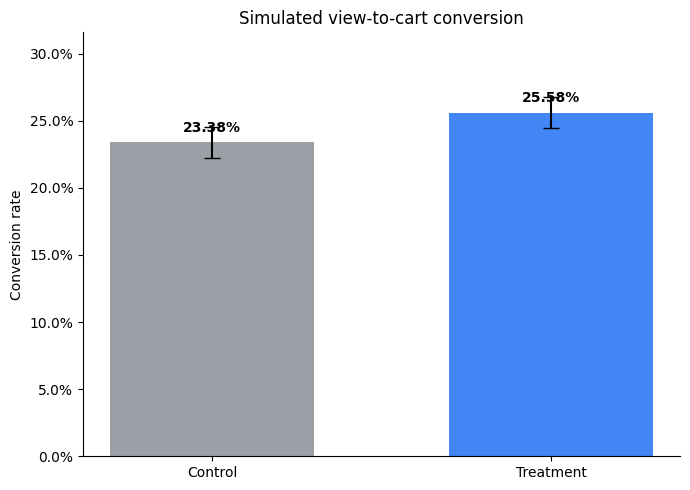

In [ ]:
# Primary metric chart
chart_rates = [
    control_observed,
    treatment_observed
]

chart_standard_errors = [
    np.sqrt(
        control_observed
        * (1 - control_observed)
        / control_users
    ),
    np.sqrt(
        treatment_observed
        * (1 - treatment_observed)
        / treatment_users
    )
]

chart_errors = [
    critical_value * value
    for value in chart_standard_errors
]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ["Control", "Treatment"],
    chart_rates,
    yerr=chart_errors,
    capsize=6,
    color=["#9AA0A6", "#4285F4"],
    width=0.6
)

ax.set_title(
    "Simulated view-to-cart conversion"
)

ax.set_ylabel("Conversion rate")
ax.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

ax.set_ylim(
    0,
    max(chart_rates) + 0.06
)

for bar, rate in zip(bars, chart_rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.008,
        f"{rate:.2%}",
        ha="center",
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 4. Simulated guardrail outcomes

Historical user-level data supplies the cart-to-purchase probability and average purchase revenue.

The simulation assumes equal underlying remove-from-cart and page-error probabilities for control and treatment. Any observed differences in these guardrails arise from random sampling.

The experiment was powered for the primary view-to-cart metric, not for rare purchase outcomes.

In [ ]:
# Simulate guardrail outcomes
guardrail_rng = np.random.default_rng(2027)

# Historical user-level results from BigQuery
historical_converted_users = 2_093
historical_complete_purchase_users = 48
historical_complete_purchase_revenue = 1_060.00

baseline_cart_to_purchase = (
    historical_complete_purchase_users
    / historical_converted_users
)

average_purchase_revenue = (
    historical_complete_purchase_revenue
    / historical_complete_purchase_users
)

# Simulated assumptions
remove_from_cart_probability = {
    "control": 0.08,
    "treatment": 0.08
}

page_error_probability = {
    "control": 0.01,
    "treatment": 0.01
}

experiment["removed_from_cart"] = 0
experiment["completed_purchase"] = 0
experiment["page_error"] = 0
experiment["revenue"] = 0.0

for variant in ["control", "treatment"]:
    variant_mask = (
        experiment["variant"] == variant
    )

    cart_mask = (
        variant_mask
        & (experiment["added_to_cart"] == 1)
    )

    cart_user_count = int(cart_mask.sum())

    experiment.loc[
        cart_mask,
        "removed_from_cart"
    ] = guardrail_rng.binomial(
        n=1,
        p=remove_from_cart_probability[variant],
        size=cart_user_count
    )

    eligible_purchase_mask = (
        cart_mask
        & (experiment["removed_from_cart"] == 0)
    )

    eligible_purchase_user_count = int(
        eligible_purchase_mask.sum()
    )

    experiment.loc[
        eligible_purchase_mask,
        "completed_purchase"
    ] = guardrail_rng.binomial(
        n=1,
        p=baseline_cart_to_purchase,
        size=eligible_purchase_user_count
    )

    variant_user_count = int(
        variant_mask.sum()
    )

    experiment.loc[
        variant_mask,
        "page_error"
    ] = guardrail_rng.binomial(
        n=1,
        p=page_error_probability[variant],
        size=variant_user_count
    )

purchase_mask = (
    experiment["completed_purchase"] == 1
)

experiment.loc[
    purchase_mask,
    "revenue"
] = np.maximum(
    guardrail_rng.normal(
        loc=average_purchase_revenue,
        scale=5.00,
        size=int(purchase_mask.sum())
    ),
    0
).round(2)

print(
    f"Historical cart-to-purchase rate: "
    f"{baseline_cart_to_purchase:.2%}"
)

print(
    f"Historical average purchase revenue: "
    f"${average_purchase_revenue:.2f}"
)

Historical cart-to-purchase rate: 2.29%
Historical average purchase revenue: $22.08


In [ ]:
# Final data-integrity validation
binary_columns = [
    "added_to_cart",
    "removed_from_cart",
    "completed_purchase",
    "page_error"
]

for column in binary_columns:
    assert set(
        experiment[column].unique()
    ).issubset({0, 1}), (
        f"{column} contains non-binary values"
    )

assert not experiment["user_id"].duplicated().any(), (
    "Duplicate user IDs detected"
)

assert (
    experiment["completed_purchase"]
    <= experiment["added_to_cart"]
).all(), (
    "A purchase exists without a basket addition"
)

assert not (
    (experiment["completed_purchase"] == 1)
    & (experiment["removed_from_cart"] == 1)
).any(), (
    "A user both removed and purchased the item"
)

assert (experiment["revenue"] >= 0).all(), (
    "Negative revenue detected"
)

assert (
    experiment.loc[
        experiment["completed_purchase"] == 0,
        "revenue"
    ] == 0
).all(), (
    "Revenue exists without a completed purchase"
)

assert experiment["data_type"].eq(
    "simulated"
).all(), (
    "Unlabelled observations detected"
)

print("All final data-integrity checks passed.")

All final data-integrity checks passed.


In [ ]:
# Guardrail summary
guardrail_summary = (
    experiment
    .groupby("variant")
    .agg(
        users=("user_id", "nunique"),
        cart_users=("added_to_cart", "sum"),
        removals=("removed_from_cart", "sum"),
        purchases=("completed_purchase", "sum"),
        page_errors=("page_error", "sum"),
        revenue=("revenue", "sum")
    )
)

# Remove floating-point display artefacts
guardrail_summary["revenue"] = (
    guardrail_summary["revenue"].round(2)
)

guardrail_summary["cart_conversion"] = (
    guardrail_summary["cart_users"]
    / guardrail_summary["users"]
)

guardrail_summary["remove_from_cart_rate"] = (
    guardrail_summary["removals"]
    / guardrail_summary["cart_users"]
)

guardrail_summary["purchase_conversion"] = (
    guardrail_summary["purchases"]
    / guardrail_summary["users"]
)

guardrail_summary["page_error_rate"] = (
    guardrail_summary["page_errors"]
    / guardrail_summary["users"]
)

guardrail_summary["revenue_per_user"] = (
    guardrail_summary["revenue"]
    / guardrail_summary["users"]
)

guardrail_summary.round(4)

,users,cart_users,removals,purchases,page_errors,revenue,cart_conversion,remove_from_cart_rate,purchase_conversion,page_error_rate,revenue_per_user
variant,,,,,,,,,,,
control,5449,1274,100,16,53,369.43,0.2338,0.0785,0.0029,0.0097,0.0678
treatment,5449,1394,123,28,57,605.07,0.2558,0.0882,0.0051,0.0105,0.1110


In [ ]:
# Guardrail proportion-testing function
def compare_proportions(
    treatment_successes,
    treatment_observations,
    control_successes,
    control_observations,
    metric_name
):
    counts = np.array([
        treatment_successes,
        control_successes
    ])

    observations = np.array([
        treatment_observations,
        control_observations
    ])

    z_statistic, metric_p_value = proportions_ztest(
        count=counts,
        nobs=observations,
        alternative="two-sided"
    )

    treatment_metric_rate = (
        treatment_successes
        / treatment_observations
    )

    control_metric_rate = (
        control_successes
        / control_observations
    )

    absolute_difference = (
        treatment_metric_rate
        - control_metric_rate
    )

    metric_standard_error = np.sqrt(
        treatment_metric_rate
        * (1 - treatment_metric_rate)
        / treatment_observations
        +
        control_metric_rate
        * (1 - control_metric_rate)
        / control_observations
    )

    metric_ci_low = (
        absolute_difference
        - critical_value * metric_standard_error
    )

    metric_ci_high = (
        absolute_difference
        + critical_value * metric_standard_error
    )

    return {
        "metric": metric_name,
        "control_rate": control_metric_rate,
        "treatment_rate": treatment_metric_rate,
        "absolute_difference": absolute_difference,
        "ci_low": metric_ci_low,
        "ci_high": metric_ci_high,
        "z_statistic": z_statistic,
        "p_value": metric_p_value
    }

In [ ]:
# Run the guardrail tests
guardrail_tests = pd.DataFrame([
    compare_proportions(
        treatment_successes=int(
            guardrail_summary.loc[
                "treatment",
                "removals"
            ]
        ),
        treatment_observations=int(
            guardrail_summary.loc[
                "treatment",
                "cart_users"
            ]
        ),
        control_successes=int(
            guardrail_summary.loc[
                "control",
                "removals"
            ]
        ),
        control_observations=int(
            guardrail_summary.loc[
                "control",
                "cart_users"
            ]
        ),
        metric_name="Remove from cart"
    ),

    compare_proportions(
        treatment_successes=int(
            guardrail_summary.loc[
                "treatment",
                "purchases"
            ]
        ),
        treatment_observations=int(
            guardrail_summary.loc[
                "treatment",
                "users"
            ]
        ),
        control_successes=int(
            guardrail_summary.loc[
                "control",
                "purchases"
            ]
        ),
        control_observations=int(
            guardrail_summary.loc[
                "control",
                "users"
            ]
        ),
        metric_name="Purchase conversion"
    ),

    compare_proportions(
        treatment_successes=int(
            guardrail_summary.loc[
                "treatment",
                "page_errors"
            ]
        ),
        treatment_observations=int(
            guardrail_summary.loc[
                "treatment",
                "users"
            ]
        ),
        control_successes=int(
            guardrail_summary.loc[
                "control",
                "page_errors"
            ]
        ),
        control_observations=int(
            guardrail_summary.loc[
                "control",
                "users"
            ]
        ),
        metric_name="Page errors"
    )
])

guardrail_tests.round(4)

,metric,control_rate,treatment_rate,absolute_difference,ci_low,ci_high,z_statistic,p_value
0,Remove from cart,0.0785,0.0882,0.0097,-0.0112,0.0307,0.9082,0.3638
1,Purchase conversion,0.0029,0.0051,0.0022,-0.0002,0.0046,1.8127,0.0699
2,Page errors,0.0097,0.0105,0.0007,-0.0030,0.0045,0.3833,0.7015


The guardrail tests are exploratory. Failure to obtain statistical significance does not prove that the treatment has no effect. Purchase conversion is rare, and the experiment was not powered specifically for purchase or revenue outcomes.

In [ ]:
# Revenue bootstrap
bootstrap_rng = np.random.default_rng(2028)
bootstrap_iterations = 10_000

control_revenue = (
    experiment.loc[
        experiment["variant"] == "control",
        "revenue"
    ]
    .to_numpy()
)

treatment_revenue = (
    experiment.loc[
        experiment["variant"] == "treatment",
        "revenue"
    ]
    .to_numpy()
)

revenue_differences = []

for _ in range(bootstrap_iterations):
    sampled_control = bootstrap_rng.choice(
        control_revenue,
        size=len(control_revenue),
        replace=True
    )

    sampled_treatment = bootstrap_rng.choice(
        treatment_revenue,
        size=len(treatment_revenue),
        replace=True
    )

    revenue_differences.append(
        sampled_treatment.mean()
        - sampled_control.mean()
    )

revenue_difference = (
    treatment_revenue.mean()
    - control_revenue.mean()
)

revenue_ci_low, revenue_ci_high = np.percentile(
    revenue_differences,
    [2.5, 97.5]
)

print(
    f"Revenue per user difference: "
    f"${revenue_difference:.3f}"
)

print(
    "95% bootstrap interval: "
    f"${revenue_ci_low:.3f} to "
    f"${revenue_ci_high:.3f}"
)

Revenue per user difference: $0.043
95% bootstrap interval: $-0.010 to $0.099


In [ ]:
# Final interpretation
print("FINAL EXPERIMENT INTERPRETATION")
print()

print(
    f"Primary conversion changed from "
    f"{control_observed:.2%} to "
    f"{treatment_observed:.2%}."
)

print(
    f"The absolute difference was "
    f"{absolute_uplift:.2%}, with a 95% "
    f"confidence interval from "
    f"{confidence_interval_low:.2%} to "
    f"{confidence_interval_high:.2%}."
)

print(f"The primary p value was {p_value:.4f}.")
print()
print(primary_decision)
print()

print(
    "The guardrail results do not establish clear "
    "deterioration, but purchase and revenue "
    "uncertainty remains substantial."
)

print(
    "Because the dataset is simulated, this result "
    "demonstrates methodology and does not support "
    "a real commercial rollout."
)

FINAL EXPERIMENT INTERPRETATION

Primary conversion changed from 23.38% to 25.58%.
The absolute difference was 2.20%, with a 95% confidence interval from 0.59% to 3.82%.
The primary p value was 0.0075.

Do not roll out yet. The result is statistically significant, but the minimum practical impact remains uncertain

The guardrail results do not establish clear deterioration, but purchase and revenue uncertainty remains substantial.
Because the dataset is simulated, this result demonstrates methodology and does not support a real commercial rollout.


In [ ]:
# Export final outputs
experiment.to_csv(
    "simulated_youtube_apparel_experiment.csv",
    index=False
)

primary_summary.reset_index().to_csv(
    "primary_metric_summary.csv",
    index=False
)

guardrail_summary.reset_index().to_csv(
    "guardrail_summary.csv",
    index=False
)

guardrail_tests.to_csv(
    "guardrail_statistical_tests.csv",
    index=False
)

print("All final outputs exported successfully.")

All final outputs exported successfully.
